# 1. Volatility Forecast Design & Baseline Models

## Objective

This notebook establishes the forecasting framework for the Volatility Forecast Validation & Challenger Analysis project.

The objective is to evaluate how effectively different volatility models forecast future market volatility using information available at the time each forecast is made.

The analysis focuses on SPY, an ETF tracking the S&P 500, using historical daily returns.

The notebook covers:

- Preparation of the return series used for forecasting.
- Definition of the forecast horizon and out-of-sample evaluation period.
- Construction of a rolling-volatility benchmark.
- Construction of an Exponentially Weighted Moving Average (EWMA) baseline.
- Validation of forecast alignment and data integrity.
- Preliminary comparison of baseline forecast behavior.

The existing Market Risk Engine already implements historical, rolling and EWMA volatility estimation. This notebook reuses those concepts in a forecasting framework, with particular attention to preventing look-ahead bias.

## Methodology

Two baseline approaches will be evaluated:

- **Rolling volatility:** estimates variance using a fixed window of recent daily returns, giving equal weight to observations within the window.
- **EWMA volatility:** estimates variance using exponentially declining weights, assigning greater importance to recent observations.

Both approaches will generate one-day-ahead variance forecasts. Their predictive performance will be evaluated in Notebook 03 against a common out-of-sample target.

A GARCH(1,1) model will be developed as the challenger in Notebook 02.

## Research Questions

1. How do rolling-volatility and EWMA forecasts respond to changes in market conditions?
2. How can forecast generation be structured to avoid using information unavailable at the forecast date?
3. Do the baseline methods provide a suitable reference for evaluating a GARCH challenger?

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices

## Data and Configuration

We use the existing Project 01 market-data utility and retain returns as a DataFrame, even though this notebook currently uses only SPY. This keeps the workflow consistent with the multi-asset structure of the Market Risk Engine.


### Configuration

The following settings define the data sample and forecasting experiment. We use SPY as the single market series and reserve the final 30% of returns for out-of-sample evaluation. The 500-observation setting controls the minimum history required before EWMA forecasts are emitted; the rolling benchmark uses the most recent 60 returns.


In [2]:
TICKERS = ["SPY"]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

INITIAL_WINDOW = 500
ROLLING_WINDOW = 60
EWMA_LAMBDA = 0.94
TEST_SIZE = 0.30

In [ ]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
)

prices = prices[["SPY"]].dropna()

returns = prices.pct_change().dropna()
returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2015-01-05,-0.018059
2015-01-06,-0.009419
2015-01-07,0.012461
2015-01-08,0.017745
2015-01-09,-0.008013


In [12]:
print(f"First observation: {returns.index.min().date()}")
print(f"Last observation:  {returns.index.max().date()}")
print(f"Number of returns: {len(returns)}")
print(f"Missing values:\n{returns.isna().sum()}")
print(f"Duplicate dates:   {returns.index.duplicated().sum()}")

First observation: 2015-01-05
Last observation:  2025-12-31
Number of returns: 2765
Missing values:
Ticker
SPY    0
dtype: int64
Duplicate dates:   0


## 2. Forecast Design & Chronological Split

### Objective

Establish a chronological evaluation framework for comparing volatility forecasts. The data will be divided into an initial estimation period and a subsequent out-of-sample test period.

The initial estimation period provides sufficient historical observations for estimating volatility. The test period evaluates forecast performance on observations not used to establish the initial forecasts.

### Design Decisions

- **Forecast horizon:** One trading day ahead.
- **Initial estimation window:** 500 daily return observations.
- **Rolling volatility window:** 60 trading days.
- **EWMA decay factor:** 0.94.
- **Out-of-sample period:** Final 30% of the available return observations.

The chronological split preserves the temporal ordering of financial data and prevents future observations from influencing the initial model evaluation.

In [23]:
# Split chronologically: earlier observations form the development sample;
# the latest 30% form the out-of-sample test period.
split_idx = int(len(returns) * (1 - TEST_SIZE))

development_returns = returns.iloc[:split_idx].copy()
test_returns = returns.iloc[split_idx:].copy()

print(f"Development observations: {len(development_returns)}")
print(f"Test observations:        {len(test_returns)}")
print(f"Development period: {development_returns.index.min().date()} "
      f"to {development_returns.index.max().date()}")
print(f"Test period:        {test_returns.index.min().date()} "
      f"to {test_returns.index.max().date()}")


Development observations: 1935
Test observations:        830
Development period: 2015-01-05 to 2022-09-09
Test period:        2022-09-12 to 2025-12-31


## 3. Rolling Volatility Benchmark

### Objective

Establish a rolling-volatility benchmark for evaluating one-day-ahead volatility forecasts.

The model estimates variance using a fixed window of the most recent 60 daily returns. Each observation receives equal weight within the window, and observations outside the window are excluded.

To prevent look-ahead bias, the forecast for day \(t\) uses returns only through day \(t-1\).

The rolling-volatility benchmark provides a simple reference against which the EWMA and GARCH models can be evaluated.

In [24]:
# Shift returns by one day so the forecast indexed at date t uses data only
# through t-1. The 60-day sample variance is therefore a one-day-ahead forecast.
rolling_variance = (
    returns
    .shift(1)
    .rolling(window=ROLLING_WINDOW)
    .var(ddof=1)
)

# Convert variance to volatility for plotting; keep variance for evaluation.
rolling_volatility = np.sqrt(rolling_variance)


In [15]:
rolling_variance_test = rolling_variance.loc[test_returns.index]
rolling_volatility_test = rolling_volatility.loc[test_returns.index]

print(f"Test observations: {len(test_returns)}")
print(f"Valid rolling forecasts:\n{rolling_variance_test.notna().sum()}")

Test observations: 830
Valid rolling forecasts:
Ticker
SPY    830
dtype: int64


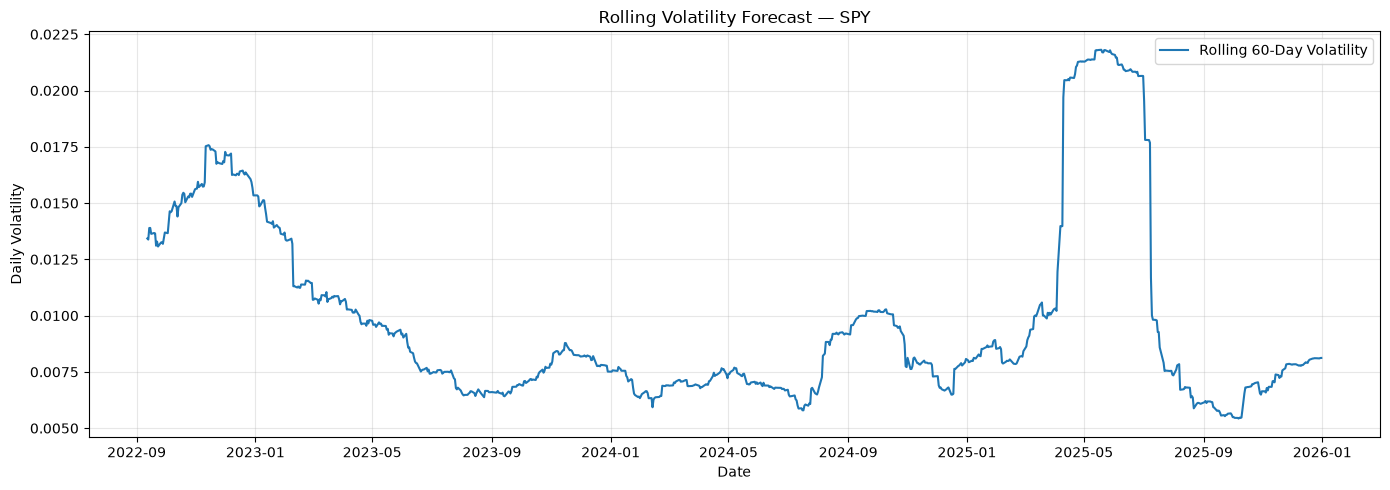

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    rolling_volatility_test.index,
    rolling_volatility_test["SPY"],
    label="Rolling 60-Day Volatility",
)

plt.title("Rolling Volatility Forecast — SPY")
plt.xlabel("Date")
plt.ylabel("Daily Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Interpretation: The benchmark uses the previous 60 returns to estimate the variance expected for the next trading day. Because the window gives equal weight to each observation, volatility estimates may change sharply when large returns enter or leave the window.
Note that these are daily volatility estimates, not annualized volatility. We will keep the units consistent across models.

## 4. EWMA Baseline

### Objective

Generate one-day-ahead volatility forecasts using the Exponentially Weighted Moving Average (EWMA) model.

Unlike the rolling-volatility benchmark, EWMA assigns exponentially declining weights to historical squared returns. Recent observations therefore have a greater influence on the estimated variance.

The decay factor is set to $\lambda = 0.94$, consistent with the EWMA implementation in Project 01.

For each forecast date $t$, the conditional variance estimate is based only on information available through date $t-1$:

$$
\sigma^2_{t|t-1}
=
\lambda \sigma^2_{t-1|t-2}
+
(1-\lambda)r_{t-1}^2
$$

This convention ensures that the forecast for a given day does not use that day's return.

The resulting forecasts will be evaluated alongside the rolling-volatility benchmark in Notebook 03.

In [ ]:
# EWMA weights recent squared returns more heavily than older observations.
# alpha = 1 - lambda is pandas' convention for the equivalent decay rate.
# min_periods delays output until 500 observations are available.
# shift(1) aligns each estimate with the next day's return, preventing look-ahead.
ewma_variance = (
    returns
    .pow(2)
    .ewm(
        alpha=1 - EWMA_LAMBDA,
        adjust=False,
        min_periods=INITIAL_WINDOW,
    )
    .mean()
    .shift(1)
)

ewma_volatility = np.sqrt(ewma_variance)


In [18]:
ewma_variance_test = ewma_variance.loc[test_returns.index]
ewma_volatility_test = ewma_volatility.loc[test_returns.index]

print(f"Test observations: {len(test_returns)}")
print(f"Valid EWMA forecasts:\n{ewma_variance_test.notna().sum()}")

Test observations: 830
Valid EWMA forecasts:
Ticker
SPY    830
dtype: int64


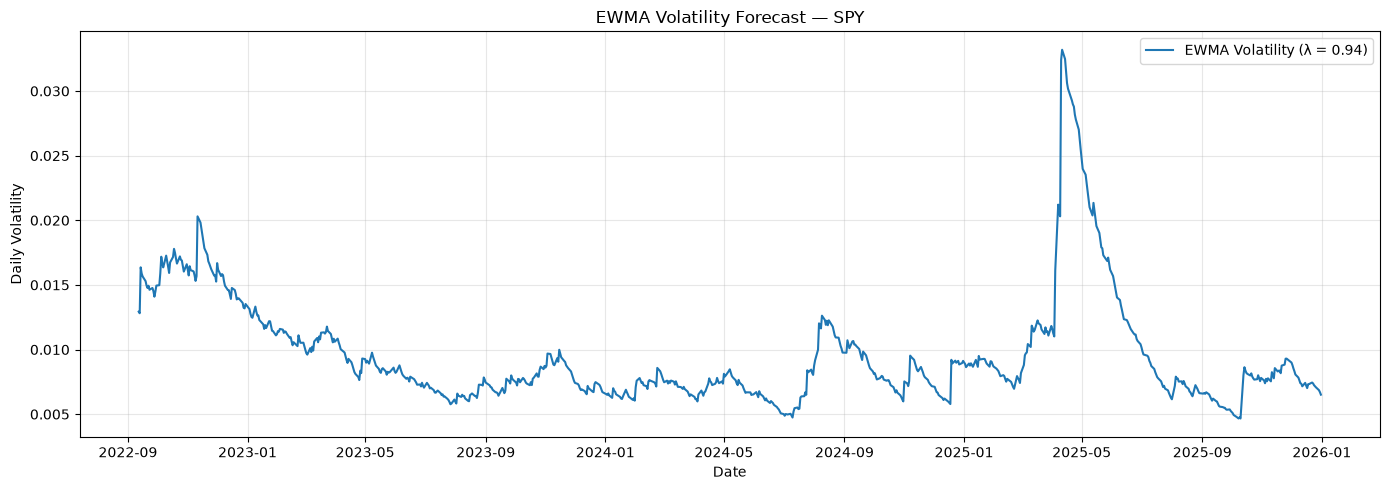

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    ewma_volatility_test.index,
    ewma_volatility_test["SPY"],
    label="EWMA Volatility (λ = 0.94)",
)

plt.title("EWMA Volatility Forecast — SPY")
plt.xlabel("Date")
plt.ylabel("Daily Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


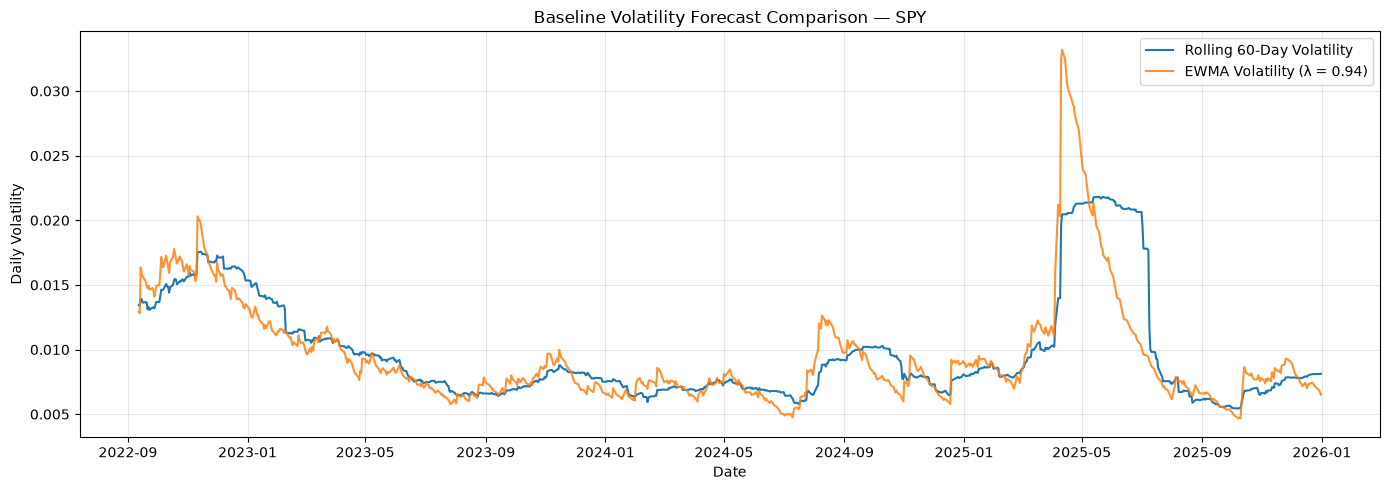

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    rolling_volatility_test.index,
    rolling_volatility_test["SPY"],
    label="Rolling 60-Day Volatility",
)

plt.plot(
    ewma_volatility_test.index,
    ewma_volatility_test["SPY"],
    label="EWMA Volatility (λ = 0.94)",
    alpha=0.85,
)

plt.title("Baseline Volatility Forecast Comparison — SPY")
plt.xlabel("Date")
plt.ylabel("Daily Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Forecast Alignment & Quality Checks

### Objective

Verify that the rolling-volatility and EWMA forecasts are suitable for a fair out-of-sample comparison.

The checks confirm that both models use the same forecast dates, contain valid variance estimates, and use only information available before the forecasted return is observed.

These checks are essential because incorrect date alignment or look-ahead bias can produce misleading model validation results.

In [21]:
# Combine actual returns and baseline forecasts
baseline_results = pd.concat(
    [
        test_returns["SPY"].rename("Actual_Return"),
        rolling_variance_test["SPY"].rename("Rolling_Variance"),
        ewma_variance_test["SPY"].rename("EWMA_Variance"),
    ],
    axis=1,
)

# Data-quality checks
print("Number of test observations:", len(baseline_results))
print("\nMissing values:")
print(baseline_results.isna().sum())

print("\nNon-positive variance forecasts:")
print(
    (baseline_results[["Rolling_Variance", "EWMA_Variance"]] <= 0)
    .sum()
)

print("\nDuplicate dates:", baseline_results.index.duplicated().sum())

baseline_results.head()

Number of test observations: 830

Missing values:
Actual_Return       0
Rolling_Variance    0
EWMA_Variance       0
dtype: int64

Non-positive variance forecasts:
Rolling_Variance    0
EWMA_Variance       0
dtype: int64

Duplicate dates: 0


,Actual_Return,Rolling_Variance,EWMA_Variance
Date,,,
2022-09-12,0.010748,0.000180,0.000167
2022-09-13,-0.043483,0.000179,0.000164
2022-09-14,0.003816,0.000193,0.000268
2022-09-15,-0.011353,0.000193,0.000252
2022-09-16,-0.007629,0.000186,0.000245


## 6. Baseline Forecast Summary

### Objective

Summarize the behavior of the rolling-volatility and EWMA forecasts over the out-of-sample period.

This section compares the distribution and variability of the forecast estimates without ranking their predictive accuracy. Formal forecast evaluation will be conducted in Notebook 03.

In [22]:
baseline_summary = baseline_results[
    ["Rolling_Variance", "EWMA_Variance"]
].agg(["mean", "std", "min", "max"]).T

baseline_summary["Mean_Volatility"] = np.sqrt(
    baseline_results[["Rolling_Variance", "EWMA_Variance"]].mean()
)

baseline_summary

,mean,std,min,max,Mean_Volatility
Rolling_Variance,0.000113,0.000110,0.000029,0.000476,0.010646
EWMA_Variance,0.000112,0.000132,0.000022,0.001102,0.010561


## Interpretation of Baseline Summary

The table summarizes the distribution of the two variance forecasts over the test period. `mean`, `std`, `min`, and `max` are calculated on **variance**, while `Mean_Volatility` is the square root of the mean variance. It is a descriptive summary, not the arithmetic mean of daily volatility forecasts.

If EWMA has a higher maximum or standard deviation, that indicates more variable forecasts and stronger reactions to some recent returns. It does **not** establish better forecast accuracy. That question is reserved for Notebook 03, where both models will be scored against the same realized outcomes using consistent loss functions.

The squared daily return will be used as a proxy for realized variance in the forecast evaluation. Because a single squared return is noisy, results should be interpreted as comparative evidence rather than a perfect observation of latent volatility.
